# Fig: $V_\mathrm{1d}(x; X, K)$ for different values of coupling strength
ISHII Hidemasa

In [1]:
using CairoMakie
import ColorSchemes as cs

In [2]:
# fixed parameters
r = 0.05
D = 0.005

0.005

In [3]:
V_1d(x, X, K, r=r) = x^4 / 4 - (1 + r) / 3 * x^3 + (r + K) / 2 * x^2 - K * X * x

""" Return numerically approximated stationary distribution p_ss ∝ exp(-V_1d / D). """
function p_ss(X, K, r=r, D=D; numx=5001, xmin=-5, xmax=5)
    x = collect(range(xmin, xmax, numx))
    pot = V_1d.(x, X, K, r)
    pot .-= minimum(pot)
    pss = exp.(-pot / D)
    @info maximum(pss)
    #pss ./= sum(pss)
    return (x=x, pss=pss)
end

p_ss

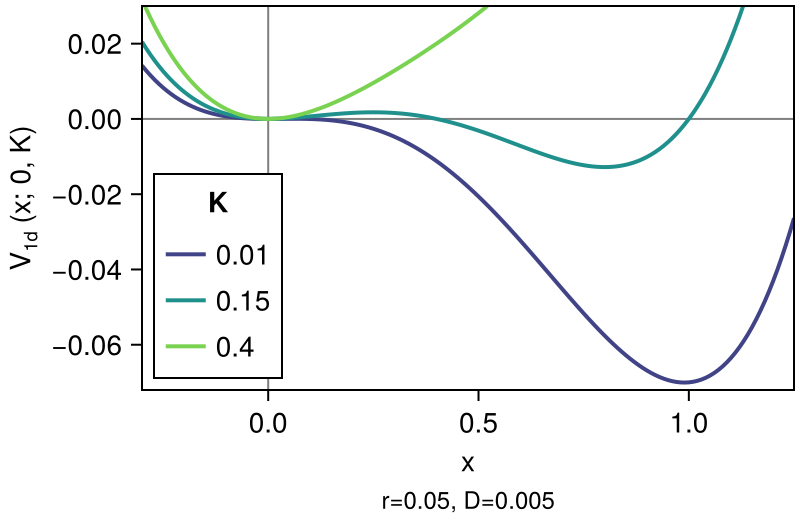

In [4]:
let X=0, plt=cs.viridis[[0.2, 0.5, 0.8]], ifsave=true
    fig = Figure(size=(400, 260), figure_padding=3)
    ax = Axis(fig[1, 1]; xlabel="x", ylabel=rich("V", subscript("1d"), " (x; 0, K)"),
        xgridvisible=false, ygridvisible=false, yautolimitmargin=(5e-3, 0)
    )
    xlims!(ax, -0.3, 1.25)
    ylims!(ax; high=0.03)
    hvlinesopts = (linewidth=1, color=:gray50)
    vlines!(ax, 0; hvlinesopts...)
    hlines!(ax, 0; hvlinesopts...)

    x = collect(-0.3:0.01:1.3)
    Kvals = [0.01, 0.15, 0.4]
    for (j, K) in enumerate(Kvals)
        lines!(ax, x, V_1d.(x, X, K), linewidth=2, color=plt[j], label="$K")
    end
    axislegend(ax, "K", position=:lb, nbanks=1)
    Label(fig[2, 1], "r=$r, D=$D", tellwidth=false, fontsize=12)
    rowgap!(fig.layout, 5)
    if ifsave save("output/fig-V1d.pdf", fig) end
    display(fig)
end;